# Part 11: Model Selection {-}

Previously, we had discussed the topic of **model selection** within the context of regression, i.e., for deciding which predictors to include in a regression model.

Here we will broaden this to cover a more general class of models, e.g., how do we select from among a list of candidate models? E.g., Normal versus t versus ... 

If we only seek to maximize the likelihood over candidate models, we will be led
to **overfitting** to the sample, since a model with more complexity (more parameters, more flexibility), will necessarily fit better to the data.

Fortunately, we can continue to use AIC and related tools for this purpose.

\newpage

## Example: Alternatives to the Lognormal Pricing Model {-}



Here, let $S_t$ denote the closing price of some equity on day $t$.

If we assume that $S_t = S_{t-1} X_t$, where $X_t$ has the lognormal$(\mu,\sigma^2)$
distribution, i.e., $\log(X_t)$ has the Normal$(\mu,\sigma^2)$ distribution.
Further assume that $X_1, X_2, \ldots$ are independent. 

This is the **lognormal pricing model** that underlies a lot of financial theory, including Black-Scholes.

One can motivate this model by assuming that $X_t = Y_1 Y_2 \cdots Y_m$, where the $Y_i$ are i.i.d.
The CLT states that $\log(X_t)$ will be approximately normal.

This model is known to not fit well to real data. In particular, log returns have heavier
tails than the normal distribution.

Consider the returns for Kellogg's (K) from
2010 to 2018:

In [1]:
import yfinance as yf
import numpy as np
Kdat = yf.download("K", start="2010-01-01",
   end="2018-12-31")
ldrK = np.log(Kdat['Adj Close']).diff()[1:]

[*********************100%***********************]  1 of 1 downloaded


\newpage

The following normal probability plot shows
the deficiencies in the normal assumption.

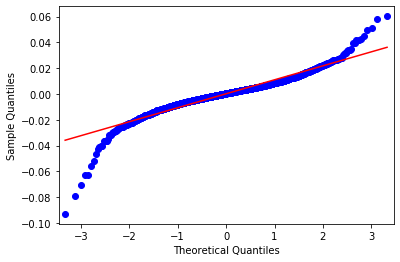

In [5]:
from statsmodels.graphics.gofplots import qqplot
import scipy.stats.distributions as spdists

qqplot(ldrK,line="s")
plt.show()

\newpage

Another way to highlight the problem with the normal fit is to compare
the **kernel density estimate (KDE)** with the best-fitting
normal distribution. The KDE is a **nonparametric** approach to estimating a density, meaning that it does not make any assumptions regarding the form of the density.

Note how the log scale is used to emphasize the problems in the tails.

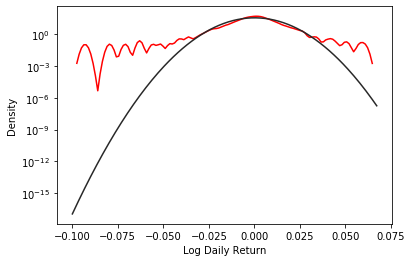

In [6]:
import seaborn as sns
from scipy.stats import norm
import matplotlib.pyplot as plt

ax = sns.distplot(ldrK, hist=False,
   kde_kws={"bw": "silverman"}, 
   color="red", fit=norm)
plt.xlabel("Log Daily Return")
plt.ylabel("Density")
plt.yscale("log")
plt.show()

The deficiencies in the normal distribution have led people to
consider alternatives. Here we will look at a few and then
compare their fit to our return data.

\newpage

## The Generalized Error Distribution (GED) {-}

(This is sometimes referred to as the **generalized normal distribution**.)

Random variable $X$ has the GED with mean $\mu$, scale
$\alpha$, and shape $\beta$ if
\begin{equation*}
   f_X(x) = \frac{\beta}{2\alpha \Gamma(1/\beta)}
   \exp\left[\left(-\frac{|x-\mu|}{\alpha}\right)^{\beta}\right]
   , \:\:\: -\infty < x< \infty, \:\:\beta >0, \:\:\alpha >0
\end{equation*}


**Comments:**

1. When $\beta=2$, this is the normal$(\mu, \alpha^2/2)$ distribution. When $\nu=1$, this is
the **double exponential** or **Laplace** distribution.

2. The distributions are symmetric around $\mu$.

3. Package `scipy.stats` includes `gennorm`.

**Exercise:** Use the code below to explore the effect of varying $\beta$ on the shape of the pdf of this distribution.

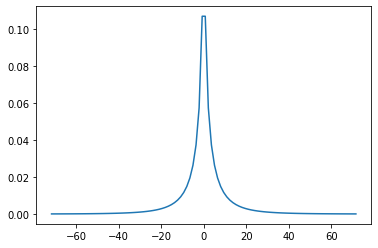

In [7]:
from scipy.stats import gennorm

beta = 0.5
x = np.linspace(gennorm.ppf(0.001, beta), 
   gennorm.ppf(0.999, beta), 100)
plt.plot(x, gennorm.pdf(x, beta))
plt.show()

\newpage

## The Nonstandard $t$-distribution {-}

Assume $T$ has the (standard) $t$-distribution with $\nu$ degrees of
freedom. Then define
\begin{equation}
   X = \mu + \sigma T
\end{equation}
where $\sigma > 0$.

This distribution with have the "shape" of the $t$-distribution, but
will have mean $\mu$ and scale $\sigma$. We will call this the **nonstandard t-distribution**.

In Python, this distribution is implemented via `scipy.stats.t`.

**Exercise:** What is the variance of a random variable with this distribution?

\answerlines{5}

\newpage

## Theodossiou's Skewed, Generalized $t$ Distribution {-}

From Theodossiou, "Financial Data and the Skewed Generalized T Distribution,"
_Management Science_, 1998.

This distribution always has its mode (peak) at zero, but can 
be **skewed (asymmetric)**.

There are four parameters:

1. $\sigma^2$, the variance. $\sigma^2 > 0$

2. $k$, which controls the height at the peak. $k>0$

3. $n$, which controls the probability in the tails. $n > 2$

4. $\lambda$, which controls the amount of skew. $-1 < \lambda < 1$

When $\lambda = 0$ and $k=2$, this matches the nonstandard $t$
distribution with $n$ degrees of freedom, variance $\sigma^2$, and
$\mu = 0$.

Equation (7) in the paper gives the mean of the distribution. As is
often the case, more complexity in the distribution leads to more
complexity in the expressions for quantities such as the mean.

We could easily generalize this distribution a bit further, and
say that $X$ has the **shifted, skewed generalized
T distribution** with shift parameter $\mu$ if $X-\mu$ has the non-shifted
distribution. Note that $E(X) = \mu$ if and only if $\lambda = 0$.

\newpage

This notebook includes functions for working with this distribution. (These are not shown in the pdf version.)

There are a pair of functions that evaluate the density of this distribution. The first is called
`dSkewT()` and uses the $(k,n,\lambda,\sigma^2,\mu)$
parameterization. The second is `dSkewTb()`, and uses the $(V,k,n,\Lambda,\mu)$ parameterization. Both of these functions include an argument `log` which enables the user to obtain the log density.

**Exercise:** See Equations (26) and (27) in
the paper (page 1655). What is the relationship between the two parameterizations, and what is the motivation
for considering the reparameterization?

\answerlines{10}

In [8]:
def dSkewTb(x, V, k, n, CapLam, mu=0, log=False):
    
    from scipy.special import beta, betaln
    
# Apply the shift
    x = x - mu
    
# Lower case lambda as a function of capital lambda

    def LittleLam(CapLam):
        return(2.0/(1+np.exp(-CapLam)) - 1.0)


# This returns log of S() evaluated at _capital lambda_.
# See Equation (4) in Theo for S() evaluated at little lambda.

    def logSofLambda(k,n,CapLam):
        return(0.5*np.log(1+(3*(LittleLam(CapLam))**2) - 
         (4*(LittleLam(CapLam)*beta(2/k,(n-1)/k))**2) * 
         (1/beta(1/k,n/k)) * 
         (1/beta(3/k, ((n-2)/k)))))


# Log of C. See Equation (2) in Theo. Note that this is in
# terms of capital lambda, instead of lower case lambda.

    def logC(V,k,n,CapLam):
        return(np.log(0.5) + np.log(k) - 1.5*betaln(1/k,n/k) + 
        0.5*betaln(3/k, (n-2)/k) +
        logSofLambda(k,n,CapLam) - V/2)


# theta as defined in Equation (3) in Theo.

    def theta(k, n, CapLam):
        return(np.exp((1/k)*np.log((k/(n-2))) + 0.5*betaln(1/k,n/k) - 
        0.5*betaln(3/k,(n-2)/k) - logSofLambda(k,n,CapLam)))


# Return either the log of the likelihood evaluated at all of the values in
# x, or return the likelihood. 

    if log:
        return(logC(V,k,n,CapLam) - ((n+1)/k) * 
          np.log(1 + (k/(n-2))*(theta(k,n,CapLam)**(-k)) *
          ((1 + np.sign(x)*LittleLam(CapLam))**(-k)) * (abs(x*np.exp(-V/2))**k)))
    else:
        return(np.exp(logC(V,k,n,CapLam) - ((n+1)/k) * 
        np.log(1 + (k/(n-2))*(theta(k,n,CapLam)**(-k)) *
        ((1 + np.sign(x)*LittleLam(CapLam))**(-k)) * (abs(x*np.exp(-V/2))**k))))
    



def dSkewT(x, k, n, lam, sigma2, mu=0, log=False):

    CapLam = np.log((lam+1)/(1-lam))

    V = np.log(sigma2)
    
    return(dSkewTb(x,V,k,n,CapLam,mu,log=log))

\newpage

**Exercise:** Use the code below to explore the shape of the density as a function of the five parameters.

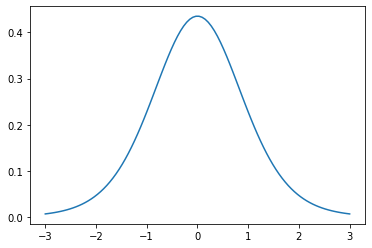

In [10]:
k = 2
n = 10
lam = 0
sigma2 = 1
mu = 0

x = np.linspace(mu-3*np.sqrt(sigma2),
    mu+3*np.sqrt(sigma2), 100)
plt.plot(x, dSkewT(x,k,n,lam,sigma2,mu))
plt.show()

Another function, `FitSkewT()`, returns the MLE of the parameters of the distribution given a vector of observations. Setting `allowshift=True` will fit the $\mu$ parameter along with the other four. The function uses `dSkewTb()` to evaluate the log likelihood, but returns the MLE in the $(k,n,\lambda,\sigma^2,\mu)$
parameterization.

**Exercise:** Try the code below to test the function.

In [11]:
def FitSkewT(dat, allowshift=False):

    from scipy.optimize import minimize
    
    # The parameter order for dSkewTb is V, k, n, CapLam, mu
    
    if(allowshift):
        initpars = [np.log(np.var(dat)), 2, 15.0, 0, np.mean(dat)]

        def negloglike(par,dat):
            return((-1)*sum(dSkewTb(dat,par[0],par[1],par[2],par[3],par[4],log=True)))    
    else:
        initpars = np.array([np.log(np.var(dat)), 1.5, 15.0, 0])
        def negloglike(par,dat):
            return((-1)*sum(dSkewTb(dat,par[0],par[1],par[2],par[3],0,log=True)))
    
    mleout = minimize(negloglike, initpars, args=(dat),method="Nelder-Mead",
                     options={'maxfev':2000})
    
    # The parameter out order is k, n, lambda, sigma2, (mu)
    if(mleout.status == 0):
        parout = mleout.x.copy()
        parout[0] = mleout.x[1]
        parout[1] = mleout.x[2]
        parout[2] = 2/(1+np.exp(-mleout.x[3])) - 1
        parout[3] = np.exp(mleout.x[0])
        return parout
    
    return(mleout.status, mleout.message)

In [12]:
from scipy.stats import t

x=t.rvs(df=15,size=1000)

FitSkewT(x, allowshift=True)

array([ 2.50942308,  7.8861331 ,  0.07165474,  1.13416555, -0.08405878])

\newpage

## Fitting the Models {-}

We will use maximum likelihood to fit all of the proposed models to the Kellogg's
data. The following Python functions make this easy:

In [13]:
normalfit = norm.fit(ldrK)
GEDfit = gennorm.fit(ldrK)
tfit = t.fit(ldrK)
skewTfit = FitSkewT(ldrK)
skewTshiftfit = FitSkewT(ldrK, allowshift=True)

In [14]:
GEDfit

(1.0068367505002245, 0.00045938387621679205, 0.007527131326779726)

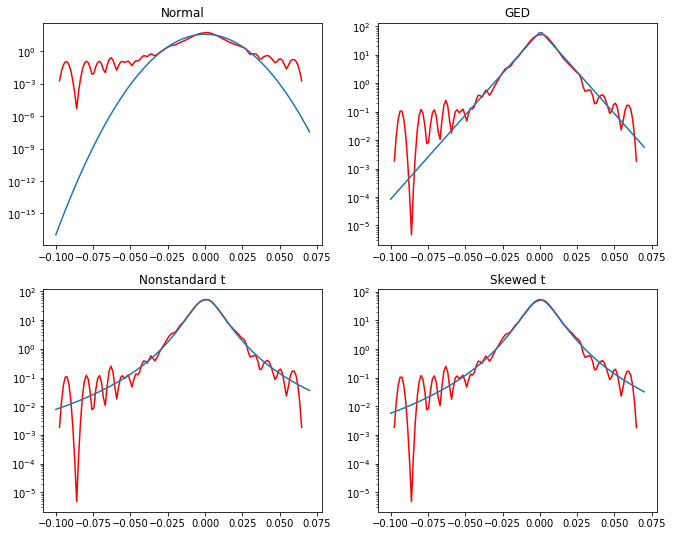

In [15]:
fig = plt.figure(figsize=(11, 9))

x = np.linspace(-0.10,0.07,100)

# Normal

ax = fig.add_subplot(2, 2, 1)
    
sns.distplot(ldrK, hist=False,
   kde_kws={"bw": "silverman"}, 
   color="red", ax=ax)

plt.plot(x,norm.pdf(x,normalfit[0],normalfit[1]))
plt.yscale("log")
plt.xlabel("")
plt.title("Normal")

# GED

ax = fig.add_subplot(2, 2, 2)
    
sns.distplot(ldrK, hist=False,
   kde_kws={"bw": "silverman"}, 
   color="red", ax=ax)

plt.plot(x,gennorm.pdf(x,GEDfit[0],GEDfit[1],GEDfit[2]))
plt.yscale("log")
plt.xlabel("")
plt.title("GED")

# Nonstandard t

ax = fig.add_subplot(2, 2, 3)
    
sns.distplot(ldrK, hist=False,
   kde_kws={"bw": "silverman"}, 
   color="red", ax=ax)

plt.plot(x,t.pdf(x,tfit[0],tfit[1],tfit[2]))
plt.yscale("log")
plt.xlabel("")
plt.title("Nonstandard t")

# Skewed t

ax = fig.add_subplot(2, 2, 4)
    
sns.distplot(ldrK, hist=False,
   kde_kws={"bw": "silverman"}, 
   color="red", ax=ax)

plt.plot(x,dSkewT(x,skewTfit[0],skewTfit[1],skewTfit[2],skewTfit[3]))
plt.yscale("log")
plt.xlabel("")
plt.title("Skewed t")

plt.show()

\newpage

Calculate the log likelihood for each of the five models:

In [16]:
print(sum(norm.logpdf(ldrK,normalfit[0],
    normalfit[1])))
print(sum(gennorm.logpdf(ldrK,GEDfit[0],
    GEDfit[1],GEDfit[2])))
print(sum(t.logpdf(ldrK,tfit[0],tfit[1],
    tfit[2])))
print(sum(dSkewT(ldrK,skewTfit[0],skewTfit[1],
    skewTfit[2],skewTfit[3],log=True)))
print(sum(dSkewT(ldrK,skewTshiftfit[0],
    skewTshiftfit[1],skewTshiftfit[2],
    skewTshiftfit[3],skewTshiftfit[4],log=True)))

7025.0977903465455
7251.410021251374
7269.972120794004
7268.690331122752
7271.711172130996


**Exercise:** Should these five models be ranked using their
likelihoods?

\answerlines{5}

\newpage

## Overfitting {-}

Model 1 is **nested** in Model 2 if Model 1 is
a special case of Model 2. In this case, the likelihood maximized under
Model 2 will necessarily be greater than or equal to the likelihood
maximized under Model 1.

In our example, Normal is nested in the GED and the nonstandard $t$ distribution
is nested in the skewed, generalized $t$ distribution with drift.

**But:** Increased likelihood may not be a sign of a better fitting model. It is
possible that we are simply **overfitting** to the available sample.

Our objective is to fit well to the **population**, not just to
the observed sample. The sample may contain **artifacts** which
appear to be real features, but would disappear with a larger sample size.

\newpage

**Example:** Suppose that a sample of size $n=50$ is drawn from the Uniform$(0,1)$
distribution. If we inspect the histogram of this sample, it is not going to be
"flat" due to natural variability.

We may be tempted to fit a Beta$(\alpha, \beta)$ distribution to this sample, in 
an effort to fit to any "features" we observe. This would be a mistake, and would
be overfitting.

See the figure below. Maximum likelihod is used to fit the Beta
distribution to the uniform data.

**Exercise:** Label the "artifacts" in this histogram.

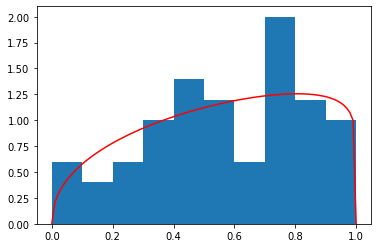

In [17]:
from scipy.stats import uniform, beta
import random

n = 50

random.seed(0)

x = uniform.rvs(size=n,random_state=6)

xbar = np.mean(x)
V = np.var(x)

alphahat = xbar*(xbar*(1-xbar)/V - 1)
betahat = (1-xbar)*alphahat/xbar

fig = plt.figure(figsize=(6, 4))
xseq = np.linspace(0,1,100)
plt.hist(x,density=True,bins=np.linspace(0,1,11))

plt.plot(xseq,beta.pdf(xseq,alphahat,betahat),color="red")
plt.show()

\newpage

Models with more parameters have greater flexibility to fit to features, but also
artifacts, in observed data. Hence, the risk of overfitting increases greatly as
we consider models with a larger number of parameters (and more complexity).

Akaike (1973) proposed a simple way to balance likelihood and model complexity, and this
has proven to be a very valuable tool for **model selection**. Define
\begin{equation*}
  {\rm AIC} = -2 \log L(\theta) + 2p
\end{equation*}
where $p$ is the number of parameters in the model. We seek the model that has the
**smallest** value of AIC.

Think of $2p$ as being a "penalty" on the likelihood for the complexity of the model.

**Exercise:** Which of our five candidate models is selected by AIC in the Kellogg's example?

\answerlines{9}

In [18]:
print(-2*sum(norm.logpdf(ldrK,normalfit[0],
    normalfit[1]))+4)
print(-2*sum(gennorm.logpdf(ldrK,GEDfit[0],
    GEDfit[1],GEDfit[2]))+6)
print(-2*sum(t.logpdf(ldrK,tfit[0],tfit[1],
    tfit[2]))+6)
print(-2*sum(dSkewT(ldrK,skewTfit[0],skewTfit[1],
    skewTfit[2],skewTfit[3],log=True))+8)
print(-2*sum(dSkewT(ldrK,skewTshiftfit[0],
    skewTshiftfit[1],skewTshiftfit[2],
    skewTshiftfit[3],skewTshiftfit[4],log=True))+10)

-14046.195580693091
-14496.820042502748
-14533.944241588008
-14529.380662245503
-14533.422344261991
